本代码旨在检验陈兆庭data_and_covariance.py输出的结果

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl  # matplotlib基础
import random

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.bottom": True,
    "xtick.top": False,
    "ytick.left": True,
    "ytick.right": False,
    "axes.grid": True,
    "grid.linestyle": "--",
})

In [12]:
def cal_freq(ch_list):
    freq_list = []
    v_min = 856.0 
    v_max = 1712.0 
    dv = 0.208984375
    assert (v_max - v_min) / dv == 4096
    for ch in ch_list:
        freq_MHz = ch * dv + v_min
        freq = freq_MHz * 1e6
        freq_list.append(freq)
    freq_list = np.array(freq_list)
    return freq_list

# 频率轴计算与筛选
n_channels = 4096
freq_axis = cal_freq(np.arange(n_channels)) / 1e6  # 转为 MHz
freq_mask = (freq_axis >= 971.) & (freq_axis <= 1023.8)
Freqs = freq_axis[freq_mask]

In [21]:
# =========================
# 读取 .npy 文件并查看形状
# =========================
file_name = "N72_sp0_theta90_f1s1d1c1_counts_3D"  # 文件路径
file_path = "dirk_results/"+file_name+".npy"  # 文件路径
# file_path = "real_results/stack_3D_rand_0.npy"  # 文件路径

data = np.load(file_path)  # 读取 numpy 数据
print(data.shape)  # 输出数据的形状

(500, 21, 21, 503)


In [22]:
# axis=(1, 2) 表示同时对这两个维度进行压缩
# 对第1、2维的索引 7:13 进行切片，然后再求和
angular_slice = slice(7,14)
summed_data = np.sum(data[:, angular_slice, angular_slice, 100:401], axis=(1, 2))
corr_matrix = np.corrcoef(summed_data, rowvar=False)  # 结果形状为 (503, 503)

print(summed_data.shape)  # 验证结果形状

(500, 301)


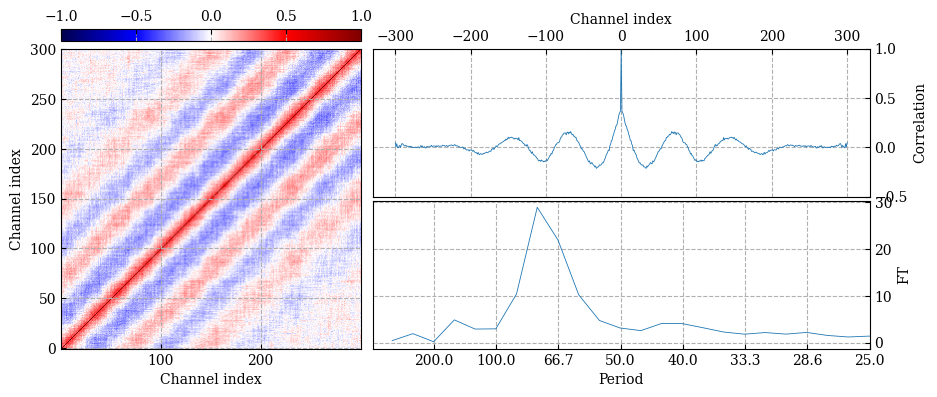

In [23]:
# =========================
# 计算“沿对角线平均”的一维数组
# =========================
# k 表示与主对角线的偏移（lag）
# k=0 为主对角线
# k>0 为上三角
# k<0 为下三角
# =========================
n = corr_matrix.shape[0]

lags = np.arange(-(n - 1), n)

diag_avg_values = []

for k in lags:

    # 提取第 k 条对角线
    diag = np.diag(corr_matrix, k=k)

    # 计算平均值
    diag_avg_values.append(np.mean(diag))

diag_avg_values = np.array(diag_avg_values)

# 保存结果
# np.save(
#     "dirk_results/" + file_name + "_1D.npy",
#     diag_avg_values
# )

# =========================
# FFT
# =========================
FFT_values = np.fft.fft(diag_avg_values)

FFT_freqs = np.fft.fftfreq(len(diag_avg_values))

FFT_power = np.abs(FFT_values)

# =========================
# 仅保留正频部分
# =========================
positive_mask = FFT_freqs > 0

FFT_freqs = FFT_freqs[positive_mask]
FFT_power = FFT_power[positive_mask]

# =========================
# 创建画布
# =========================
fig = plt.figure(figsize=(7, 4))

# =========================
# 左侧 heatmap
# =========================
ax0 = fig.add_axes([
    0.06,   # left
    0.12,   # bottom
    0.58,   # width
    0.75    # height
])

im = ax0.imshow(
    corr_matrix,
    cmap="seismic",
    origin="lower",
    aspect="auto",
    vmin=-1,
    vmax=1
)

# 保持热力图正方形
ax0.set_box_aspect(1)

ax0.set_xlabel("Channel index")
ax0.set_ylabel("Channel index")

ax0.set_ylim(-0.5, n - 0.5)

# 仅显示部分 x ticks
ax0.set_xticks([100, 200])

# =========================
# 左图 y 轴放左侧
# =========================
ax0.yaxis.tick_left()
ax0.yaxis.set_label_position("left")

# =========================
# 强制刷新布局
# =========================
fig.canvas.draw()

pos0 = ax0.get_position()

# =========================
# colorbar
# 与热力图严格同宽
# =========================
cax = fig.add_axes([
    pos0.x0,
    pos0.y1 + 0.02,
    pos0.width,
    0.03
])

cb = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal"
)

cax.xaxis.set_ticks_position("top")
cax.xaxis.set_label_position("top")

# =========================
# 右侧子图布局
# =========================
right_left = pos0.x1 + 0.017

right_width = 0.71

# 上下子图间距
vertical_gap = 0.01

# 总高度与左图一致
total_height = pos0.height

# 每个子图高度
sub_height = (total_height - vertical_gap) / 2

# =========================
# 右上：diagonal average
# =========================
ax1 = fig.add_axes([
    right_left,
    pos0.y1 - sub_height,
    right_width,
    sub_height
])

ax1.plot(
    lags,
    diag_avg_values,
    lw=0.6
)

# =========================
# x 轴放顶部
# =========================
ax1.xaxis.tick_top()
ax1.xaxis.set_label_position("top")

ax1.set_xlabel("Channel index")

ax1.set_ylabel("Correlation")

ax1.set_ylim(-0.5, 1)

# =========================
# 右图 y 轴放右侧
# =========================
ax1.yaxis.tick_right()
ax1.yaxis.set_label_position("right")

# =========================
# 右下：FFT
# =========================
ax2 = fig.add_axes([
    right_left,
    pos0.y0,
    right_width,
    sub_height
])

ax2.plot(
    FFT_freqs,
    FFT_power,
    lw=0.6
)

# =========================
# x 轴放底部（默认）
# =========================
ax2.xaxis.tick_bottom()
ax2.xaxis.set_label_position("bottom")

# =========================
# 设置 x 范围
# =========================
ax2.set_xlim(0.0001, 0.04)

# =========================
# 将 x 刻度标签改为倒数
# Period = 1 / frequency
# =========================
xticks = ax2.get_xticks()

# 去掉非正值
xticks = xticks[xticks > 0]

ax2.set_xticks(xticks)

ax2.set_xticklabels([
    f"{1/x:.1f}"
    for x in xticks
])

ax2.set_xlabel("Period")

ax2.set_ylabel("FT")

# =========================
# 右图 y 轴放右侧
# =========================
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")

# =========================
# 保存图像
# =========================
plt.savefig(
    file_name + ".pdf",
    bbox_inches="tight"
)

plt.show()

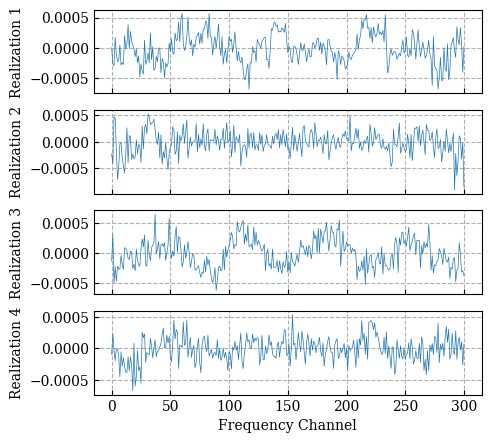

In [24]:
N_REALIZATIONS = 4   # 实现次数
N_SAMPLES = 1        # 每次抽样数量

# 创建 5 个子图（竖排）
fig, axes = plt.subplots(N_REALIZATIONS, 1, figsize=(5, 5), sharex=True)

for i in range(N_REALIZATIONS):
    # 每次随机选不重复索引
    INDICES = random.sample(range(0, 499), N_SAMPLES)
    
    # 收集数据
    SELECTED = [summed_data[idx] for idx in INDICES]
    
    # 计算均值
    MEAN = np.mean(SELECTED, axis=0)
    
    # 在对应子图上画图
    axes[i].plot(MEAN, lw=0.5)
    # axes[i].set_ylim(-0.0017, 0.0017)
    axes[i].set_ylabel(f"Realization {i+1}")  # 可选：标记第几次实现

# 公共标签
axes[-1].set_xlabel("Frequency Channel")

plt.savefig("pdf.pdf")  # 保存为 PDF，自动裁剪边距
plt.show()